In [1]:
import os

import cmcrameri as cmc  # noqa: F401
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import yaml
from matplotlib.ticker import MaxNLocator
from metpy.units import units
from unseen_awg.plotting_utils import add_headers, add_label_to_axes

from analyses.utils import (
    extract_datapoints_in_months,
    extract_datapoints_in_years,
    extract_n_years_from_trajectory,
    load_trajectories,
    stack_to_dim,
)

In [2]:
mpl.rc_file("../../matplotlibrc")
ALPHABET = "abcdefghijklmnopq"

In [3]:
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [4]:
COORDS_LEIPZIG = {
    "latitude": 51.340199,
    "longitude": 12.360103,
}


"""
{
    "latitude": 51.340199,
    "longitude": 12.360103,
}
{"latitude": 49.8, "longitude": -1}
"""

"""


"""


N_YEARS = 21
YEAR_MIN = 2003
YEAR_MAX = YEAR_MIN + N_YEARS - 1

SEASONS = {
    "DJF": np.array([12, 1, 2]),
    "MAM": np.array([3, 4, 5]),
    "JJA": np.array([6, 7, 8]),
    "SON": np.array([9, 10, 11]),
}

THRESHOLD = 1

In [5]:
long_var_names = {
    "t2m": r"$T_\text{2m, mean}$",
    "mn2t": r"$T_\text{2m, min}$",
    "mx2t": r"$T_\text{2m, max}$",
}

In [ ]:
ds_era5 = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_era5",
        "combined_facc0e91.zarr",
    ),
    decode_timedelta=True,
)
ds_reforecasts_bias_corrected = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_reforecasts",
        "rechunk_combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d.zarr",
    ),
    decode_timedelta=True,
)

ds_era5 = ds_era5.rename(long_var_names)
ds_reforecasts_bias_corrected = ds_reforecasts_bias_corrected.rename(long_var_names)

ds_reforecasts_bias_corrected["tp"] = (
    ds_reforecasts_bias_corrected["tp"]
    .where(
        ds_reforecasts_bias_corrected["tp"].metpy.quantify() > 1 * units.millimeter, 0
    )
    .metpy.dequantify()
)

ds_era5["tp"] = (
    ds_era5["tp"]
    .where(ds_era5["tp"].metpy.quantify() > 1 * units.millimeter, 0)
    .metpy.dequantify()
)

In [9]:
n_seeds = 100
sigma = 2.5
blocksize = 30

dir_trajectories = "wg_reforecasts_5e06172f_f40e9460_1e69bda9_d13ad10f"
paths_trajectories = [
    os.path.join(
        paths["dir_simulations"], dir_trajectories, f"{seed}_{sigma:g}_{blocksize}"
    )
    for seed in range(n_seeds)
]

In [10]:
ds_era5 = ds_era5.assign_coords({"valid_time": ds_era5.init_time + ds_era5.lead_time})
ds_reforecasts_bias_corrected = ds_reforecasts_bias_corrected.assign_coords(
    {
        "valid_time": ds_reforecasts_bias_corrected.init_time
        + ds_reforecasts_bias_corrected.lead_time
    }
)

xr.testing.assert_equal(ds_era5.latitude, ds_reforecasts_bias_corrected.latitude)
xr.testing.assert_equal(ds_era5.longitude, ds_reforecasts_bias_corrected.longitude)


ground_truth = (
    (
        extract_datapoints_in_years(
            stack_to_dim(ds_era5),
            year_max=YEAR_MAX,
            year_min=YEAR_MIN,
        ).swap_dims({"datapoint": "valid_time"})
    )
    .expand_dims()
    .sel(COORDS_LEIPZIG, method="nearest")
)

excl_vars = ["tp"]
sel_vars = [v for v in ground_truth.data_vars if v not in excl_vars]
sel_vars = [
    r"$T_\text{2m, mean}$",
    r"$T_\text{2m, max}$",
    r"$T_\text{2m, min}$",
]

trajectories = load_trajectories(paths_trajectories)

print("load trajectories")
trimmed_trajs = []
for traj in trajectories:
    trimmed_trajs.append(
        extract_n_years_from_trajectory(
            traj=traj,
            n_years=N_YEARS,
            new_start_year=ground_truth.valid_time.dt.year.min().data,
        )
    )
trimmed_trajs = xr.combine_by_coords(trimmed_trajs)


load trajectories


In [11]:
def plot_univariate(coords):
    quantiles = np.linspace(0.025, 0.975, 40)

    fig = plt.figure()
    fig.set_figheight(5.5)

    # Create main GridSpec with two rows
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.5], hspace=0.08)

    # Create SubGridSpecs for top and bottom sections
    gs_top = gs[0].subgridspec(len(sel_vars), len(SEASONS), hspace=0, wspace=0)
    gs_bottom = gs[1].subgridspec(1, len(SEASONS), wspace=0)

    # Create axes for top section with shared x and y
    axs_top = np.empty((len(sel_vars), len(SEASONS)), dtype=object)
    share_ax_top = None
    for i in range(len(sel_vars)):
        for j in range(len(SEASONS)):
            if share_ax_top is None:
                axs_top[i, j] = fig.add_subplot(gs_top[i, j])
                share_ax_top = axs_top[i, j]
            else:
                axs_top[i, j] = fig.add_subplot(
                    gs_top[i, j], sharex=share_ax_top, sharey=share_ax_top
                )

    # Hide tick labels for non-edge axes in top section
    for i in range(len(sel_vars)):
        for j in range(len(SEASONS)):
            if i < len(sel_vars) - 1:  # Not bottom row
                plt.setp(axs_top[i, j].get_xticklabels(), visible=False)
            if j > 0:  # Not leftmost column
                plt.setp(axs_top[i, j].get_yticklabels(), visible=False)

    # Create axes for bottom section with shared x and y
    axs_bottom = np.empty(len(SEASONS), dtype=object)
    share_ax_bottom = None
    for j in range(len(SEASONS)):
        if share_ax_bottom is None:
            axs_bottom[j] = fig.add_subplot(gs_bottom[0, j])
            share_ax_bottom = axs_bottom[j]
        else:
            axs_bottom[j] = fig.add_subplot(
                gs_bottom[0, j], sharex=share_ax_bottom, sharey=share_ax_bottom
            )

    # Hide tick labels for non-edge axes in bottom section
    for j in range(len(SEASONS)):
        if j > 0:  # Not leftmost column
            plt.setp(axs_bottom[j].get_yticklabels(), visible=False)

    temp_min = (
        ds_reforecasts_bias_corrected.sel(coords, method="nearest")[sel_vars]
        .quantile(0.001)
        .compute()
        .to_dataarray()
        .min(dim="variable")
    )
    temp_max = (
        ds_reforecasts_bias_corrected.sel(coords, method="nearest")[sel_vars]
        .quantile(0.999)
        .compute()
        .to_dataarray()
        .max(dim="variable")
    )
    tp_max = (
        ds_reforecasts_bias_corrected.sel(coords, method="nearest")["tp"]
        .quantile(0.999)
        .compute()
    )

    for i, (name_season, months) in enumerate(SEASONS.items()):
        ground_truth = (
            (
                extract_datapoints_in_years(
                    stack_to_dim(ds_era5),
                    year_max=YEAR_MAX,
                    year_min=YEAR_MIN,
                ).swap_dims({"datapoint": "valid_time"})
            )
            .expand_dims()
            .sel(coords, method="nearest")
        )

        print("compute aggregates for ground truth")
        data_gt = extract_datapoints_in_months(ground_truth, months=months).load()[
            sel_vars
        ]
        data = (
            ds_reforecasts_bias_corrected.sel(coords, method="nearest")
            .drop_vars("valid_time")
            .sel(trimmed_trajs.load())
            .rename({"out_time": "valid_time"})
        )

        data = extract_datapoints_in_months(data, months=months).load()[sel_vars]

        # Create the KDE plot
        for j, var in enumerate(sel_vars):
            for s in data["seed"].values:
                # Select the data for the current seed
                da_single_seed = (
                    data[var].sel(seed=s).to_dataframe(name="value").reset_index()
                )

                # Plot the KDE for this seed with the specified color
                sns.kdeplot(
                    ax=axs_top[j, i],
                    data=da_single_seed,
                    x="value",
                    color="C1",
                    fill=False,
                    alpha=0.3,
                    label="Generated"
                    if s == data["seed"].values[0] and i == 0 and j == 0
                    else None,
                )

            sns.kdeplot(
                ax=axs_top[j, i],
                data=data_gt[var].to_dataframe(name="value").reset_index(),
                x="value",
                fill=False,
                color="k",
                label="ERA5" if i == 0 and j == 0 else None,
            )

            axs_top[j, i].set_xlim([temp_min, temp_max])
            axs_top[j, i].set_xlabel("$T$ [°C]")
            axs_top[j, i].set_ylabel(var + " density")
            add_label_to_axes(
                ax=axs_top[j, i],
                ha="left",
                va="top",
                ax_xpos=0.05,
                ax_ypos=0.9,
                label=f"({ALPHABET[j + i * (len(sel_vars) + 1)]})",
            )

        tp_gt = extract_datapoints_in_months(ground_truth, months=months).load()["tp"]
        tp = (
            ds_reforecasts_bias_corrected.sel(coords, method="nearest")
            .drop_vars("valid_time")
            .sel(trimmed_trajs.load())
            .rename({"out_time": "valid_time"})
        )["tp"]
        tp = extract_datapoints_in_months(tp, months=months).load()
        tp_quantiles_wet_days = []
        for s in tp["seed"].values:
            # Select the data for the current seed
            tp_single_seed = tp.sel(seed=s)

            tp_single_seed = tp_single_seed.where(
                tp_single_seed >= THRESHOLD, drop=True
            )

            tp_quantiles_wet_days.append(
                tp_single_seed.quantile(quantiles).expand_dims(seed=[s])
            )
        tp_quantiles_wet_days = xr.combine_by_coords(tp_quantiles_wet_days)["tp"]
        tp_gt = tp_gt.where(tp_gt >= THRESHOLD, drop=True)
        tp_quantiles_wet_days_gt = tp_gt.quantile(quantiles)
        positions = tp_quantiles_wet_days_gt.values

        mins = tp_quantiles_wet_days.min("seed")
        maxs = tp_quantiles_wet_days.max("seed")

        # Plot error bars
        for pos, minimum, maximum in zip(positions, mins, maxs):
            axs_bottom[i].plot([pos, pos], [minimum, maximum], c="C0")

        axs_bottom[i].set_aspect("equal")
        axs_bottom[i].plot([0, tp_max], [0, tp_max], linestyle="dashed", color="k")
        axs_bottom[i].set_xlim([0, tp_max])
        axs_bottom[i].set_xlabel("$Q$ ERA5 [mm]")
        axs_bottom[i].set_ylim([0, tp_max])
        add_label_to_axes(
            ax=axs_bottom[i],
            ha="left",
            va="top",
            ax_xpos=0.05,
            ax_ypos=0.9,
            label=f"({ALPHABET[len(sel_vars) + i * (len(sel_vars) + 1)]})",
        )

    for i, season in enumerate(SEASONS):
        axs_top[0, i].set_title(season)

    axs_bottom[0].set_ylabel("$Q$ generated range [mm]", fontsize="medium")

    for ax in axs_top.flat:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.set_yticks([0, 0.1])

    # Set minimum number of ticks for bottom block
    for ax in np.atleast_1d(axs_bottom).flat:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    return fig


compute aggregates for ground truth
compute aggregates for ground truth
compute aggregates for ground truth
compute aggregates for ground truth


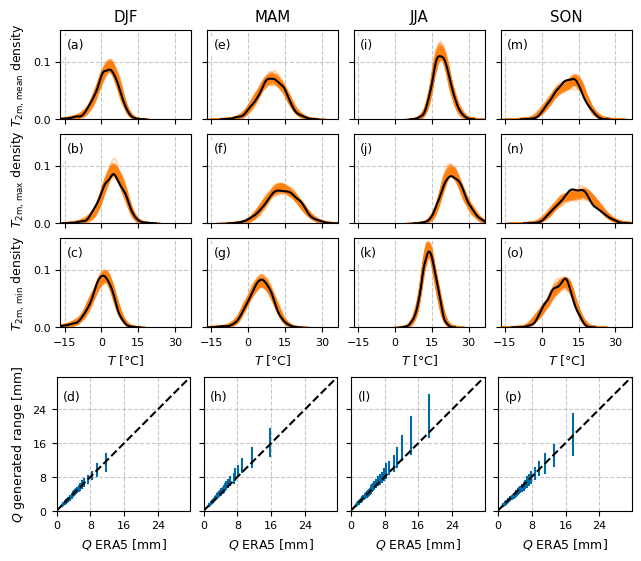

In [12]:
fig = plot_univariate(COORDS_LEIPZIG)
fig.savefig(os.path.join(paths["dir_images"], "univariate_leipzig.pdf"), dpi=300)

In [13]:
n = 10
seed = 0

rng = np.random.default_rng(seed=seed)

random_lats = rng.choice(ds_reforecasts_bias_corrected.latitude, size=n)
random_lons = rng.choice(ds_reforecasts_bias_corrected.longitude, size=n)

random_coords = [
    {"latitude": lat, "longitude": lon} for (lat, lon) in zip(random_lats, random_lons)
]

In [ ]:
for i, coords in enumerate(random_coords):
    fig = plot_univariate(coords)
    fig.suptitle(
        f"Latitude: {coords['latitude']:g}°, Longitude: {coords['longitude']:g}°"
    )
    # plt.tight_layout()
    fig.savefig(os.path.join(paths["dir_images"], f"univariate_random_{i}.png"))
    plt.close()

compute aggregates for ground truth
compute aggregates for ground truth
compute aggregates for ground truth
compute aggregates for ground truth


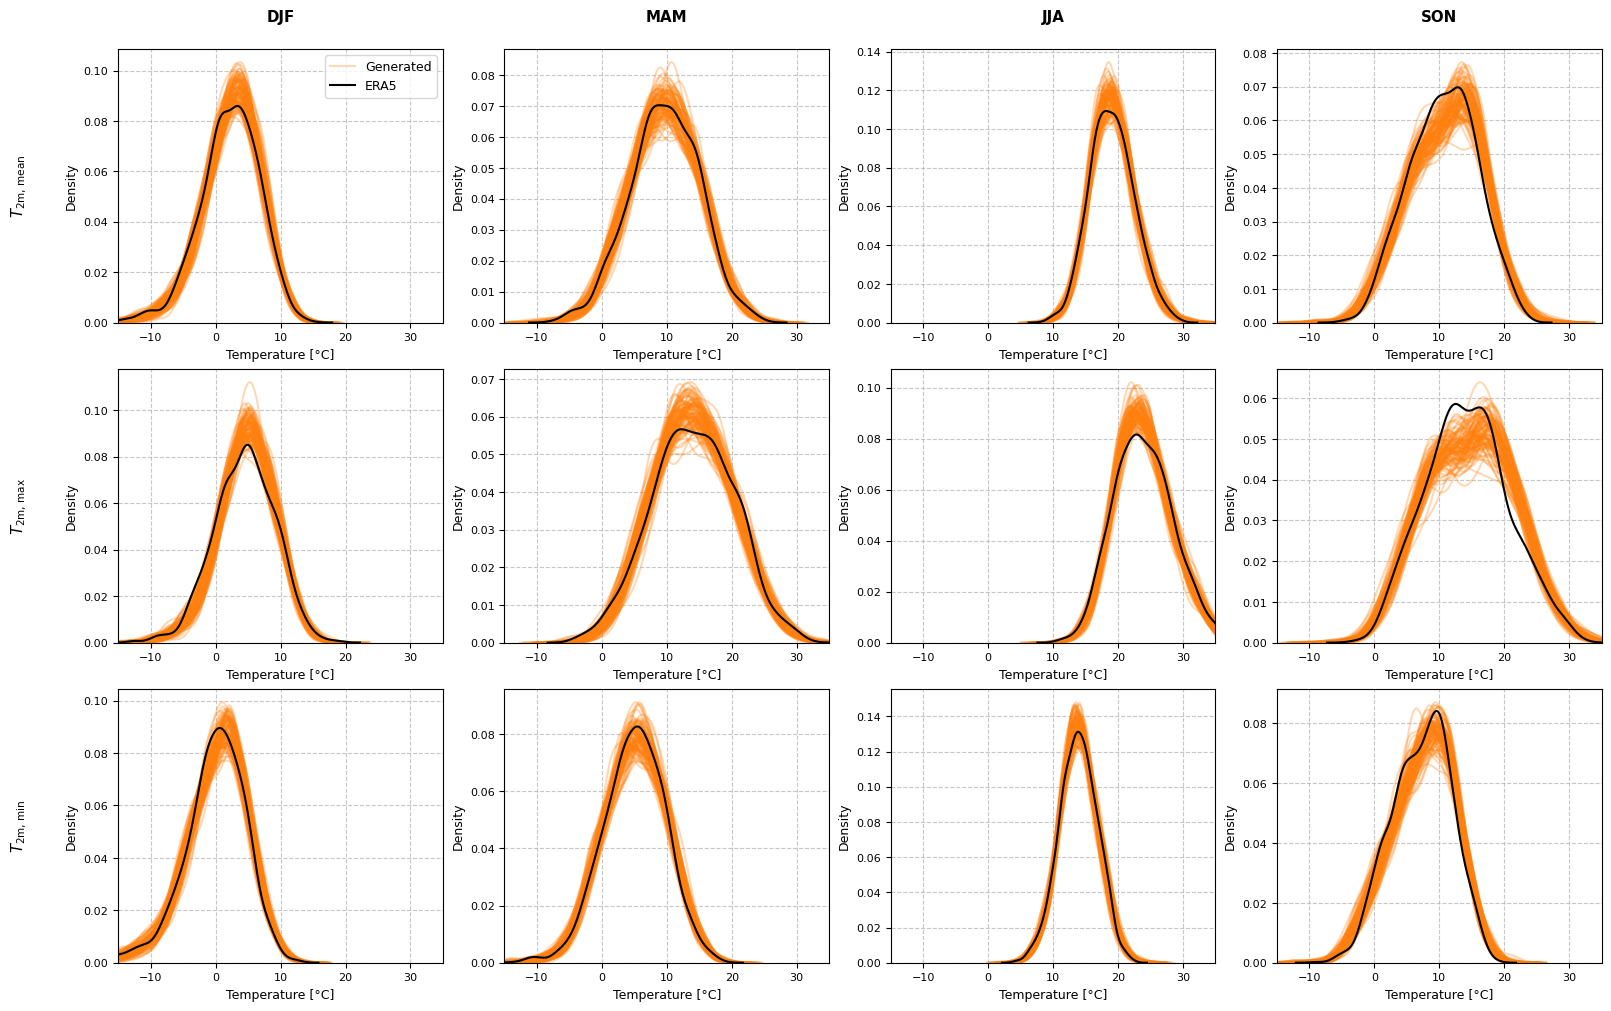

In [15]:
fig, axes = plt.subplots(len(sel_vars), len(SEASONS), figsize=(16, 10))

for i, (name_season, months) in enumerate(SEASONS.items()):
    print("compute aggregates for ground truth")
    data_gt = extract_datapoints_in_months(ground_truth, months=months).load()[sel_vars]
    data = (
        ds_reforecasts_bias_corrected.sel(COORDS_LEIPZIG, method="nearest")
        .drop_vars("valid_time")
        .sel(trimmed_trajs.load())
        .rename({"out_time": "valid_time"})
    )

    data = extract_datapoints_in_months(data, months=months).load()[sel_vars]

    # Create the KDE plot
    for j, var in enumerate(sel_vars):
        for s in data["seed"].values:
            # Select the data for the current seed
            da_single_seed = (
                data[var].sel(seed=s).to_dataframe(name="value").reset_index()
            )

            # Plot the KDE for this seed with the specified color
            sns.kdeplot(
                ax=axes[j, i],
                data=da_single_seed,
                x="value",
                color="C1",
                fill=False,
                alpha=0.3,
                label="Generated"
                if s == data["seed"].values[0] and i == 0 and j == 0
                else None,
            )

        sns.kdeplot(
            ax=axes[j, i],
            data=data_gt[var].to_dataframe(name="value").reset_index(),
            x="value",
            fill=False,
            color="k",
            label="ERA5" if i == 0 and j == 0 else None,
        )
        axes[j, i].set_xlabel("Temperature [°C]")
        axes[j, i].set_xlim(-15, 35)

# Add legend to top left panel
axes[0, 0].legend(loc="upper right")

font_kwargs = dict(fontweight="bold", fontsize="large")

add_headers(
    fig,
    col_headers=list(SEASONS.keys()),
    row_headers=sel_vars,
    col_pad=20,
    row_pad=60,
    **font_kwargs,
)

# plt.tight_layout()
plt.savefig(os.path.join(paths["dir_images"], "temperatures_kde.png"))

q-q plot for wet days:

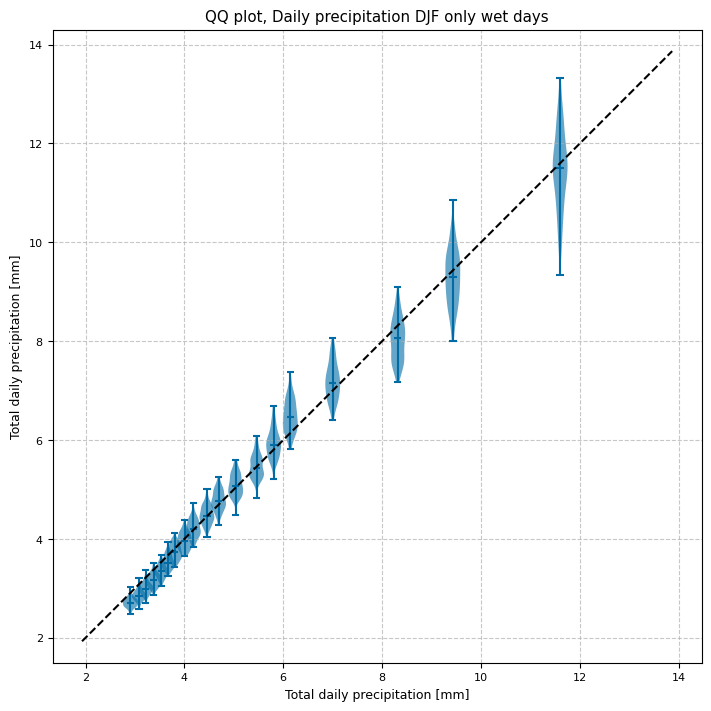

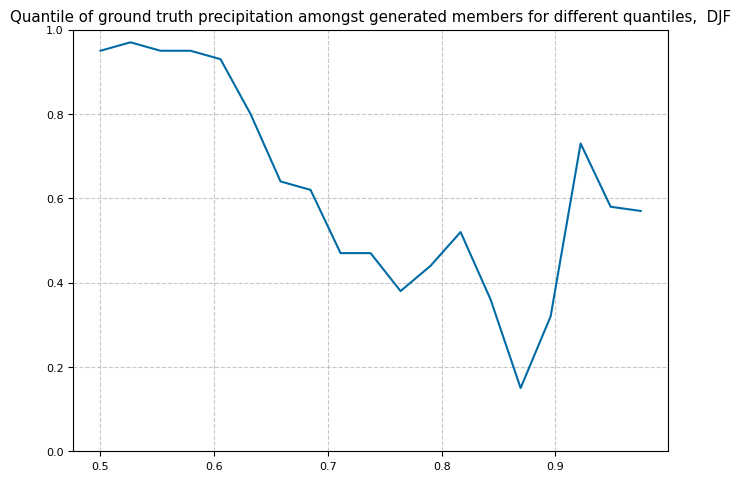

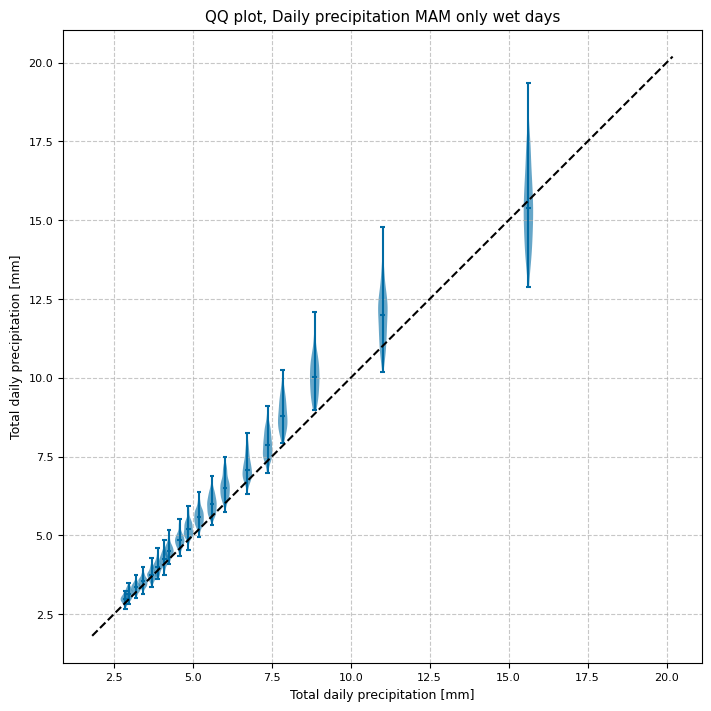

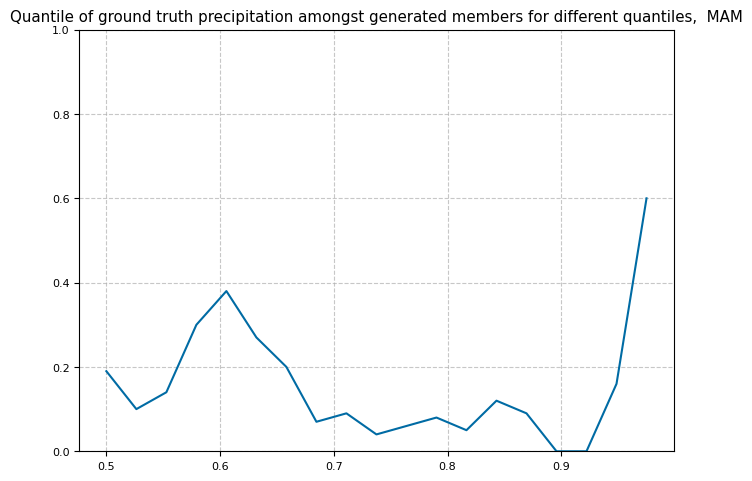

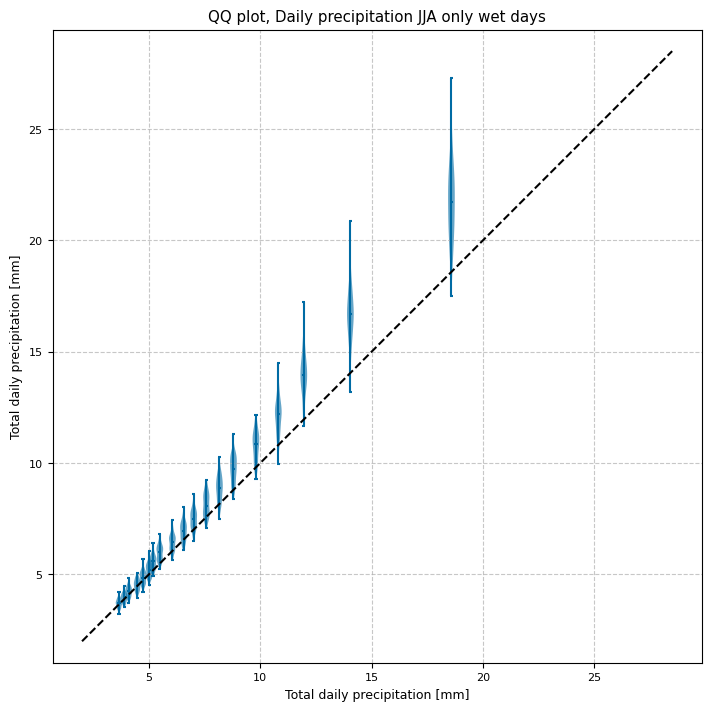

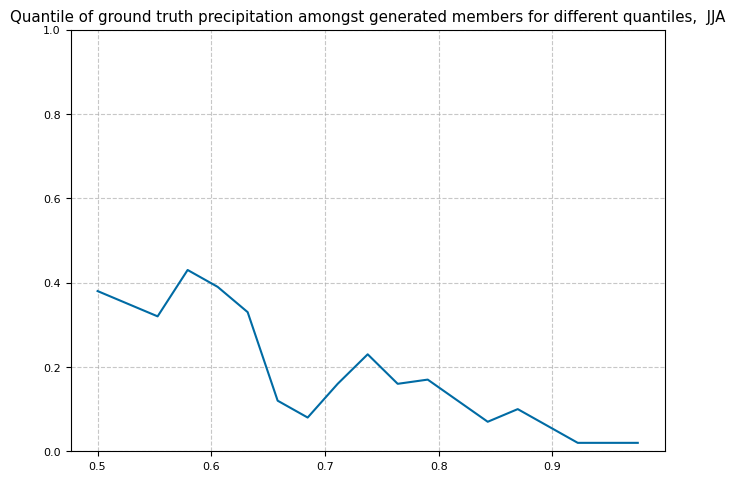

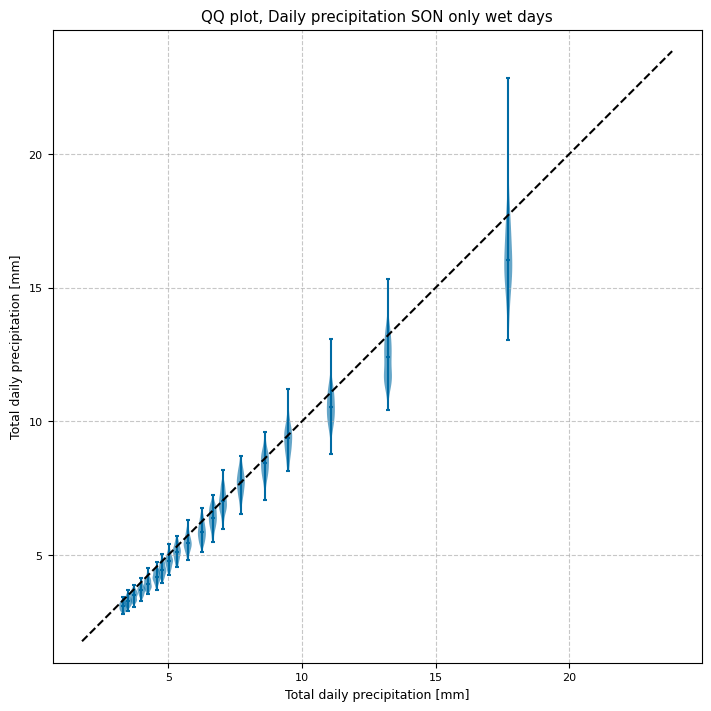

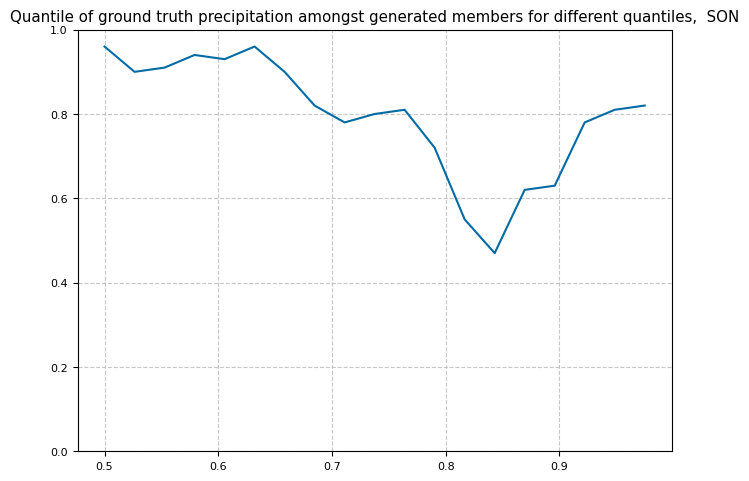

In [16]:
quantiles = np.linspace(0.5, 0.975, 19)

for i, (name_season, months) in enumerate(SEASONS.items()):
    tp_gt = extract_datapoints_in_months(ground_truth, months=months).load()["tp"]
    tp = (
        ds_reforecasts_bias_corrected.sel(COORDS_LEIPZIG, method="nearest")
        .drop_vars("valid_time")
        .sel(trimmed_trajs.load())
        .rename({"out_time": "valid_time"})
    )["tp"]

    tp = extract_datapoints_in_months(tp, months=months).load()

    tp_quantiles_wet_days = []
    for s in tp["seed"].values:
        # Select the data for the current seed
        tp_single_seed = tp.sel(seed=s)

        tp_single_seed = tp_single_seed.where(tp_single_seed >= THRESHOLD, drop=True)

        tp_quantiles_wet_days.append(
            tp_single_seed.quantile(quantiles).expand_dims(seed=[s])
        )
    tp_quantiles_wet_days = xr.combine_by_coords(tp_quantiles_wet_days)["tp"]

    tp_gt = tp_gt.where(tp_gt >= THRESHOLD, drop=True)
    tp_quantiles_wet_days_gt = tp_gt.quantile(quantiles)

    plt.figure(figsize=(7, 7))
    # Sample fewer quantiles for cleaner visualization

    positions = tp_quantiles_wet_days_gt.values
    violin_data = tp_quantiles_wet_days

    parts = plt.violinplot(
        violin_data, positions=positions, widths=0.3, showmedians=True
    )
    for pc in parts["bodies"]:
        # pc.set_facecolor('lightblue')
        pc.set_alpha(0.6)
        # pc.set_edgecolor('blue')
        # pc.set_linewidth(1)

    plt.axis("equal")
    # plt.xlim((0, 20))
    # plt.ylim((0, 20))
    plt.title("QQ plot, Daily precipitation " + name_season + " only wet days")
    plt.xlabel("Total daily precipitation [mm]")
    plt.ylabel("Total daily precipitation [mm]")
    xlim = plt.xlim()
    ylim = plt.ylim()
    vmin = min(xlim[0], ylim[0])
    vmax = max(xlim[1], ylim[1])
    plt.plot([vmin, vmax], [vmin, vmax], linestyle="dashed", color="k")

    plt.savefig(os.path.join(paths["dir_images"], f"qq_precip_{name_season}.png"))
    plt.show()

    rank_gt = (tp_quantiles_wet_days_gt > tp_quantiles_wet_days).mean("seed")
    plt.plot(rank_gt["quantile"], rank_gt)
    plt.ylim((0, 1))
    plt.title(
        "Quantile of ground truth precipitation amongst generated members for different quantiles,  "
        + name_season
    )
    plt.savefig(os.path.join(paths["dir_images"], f"qq_rank_precip_{name_season}.png"))
    plt.show()


compute aggregates for ground truth


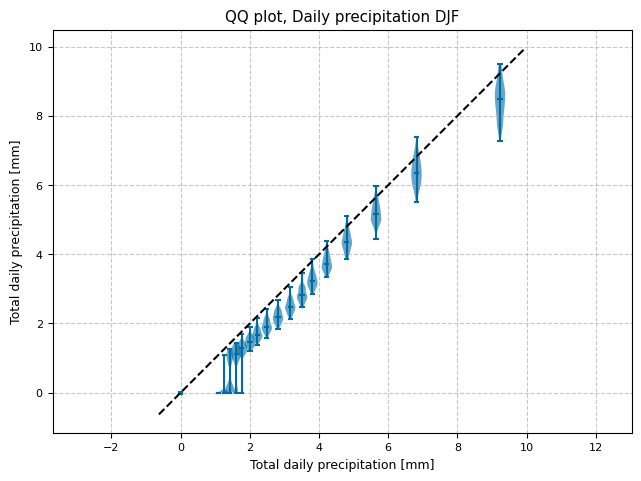

compute aggregates for ground truth


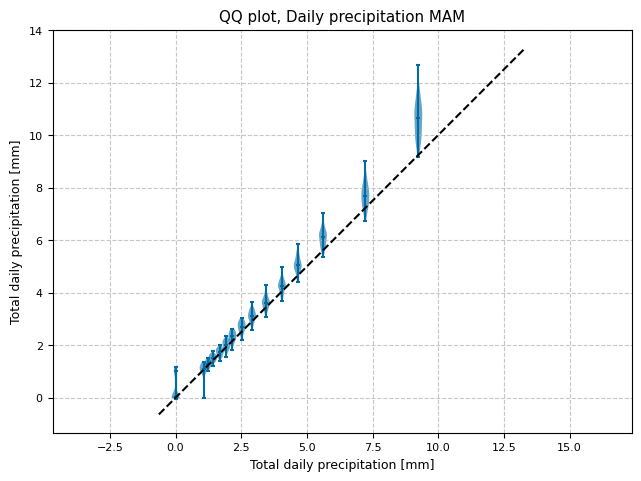

compute aggregates for ground truth


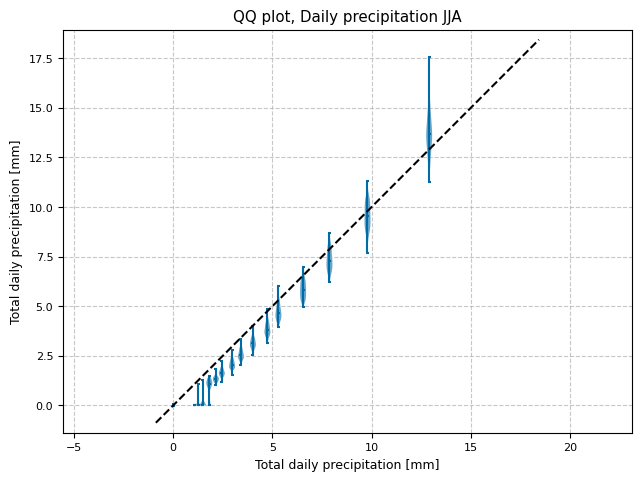

compute aggregates for ground truth


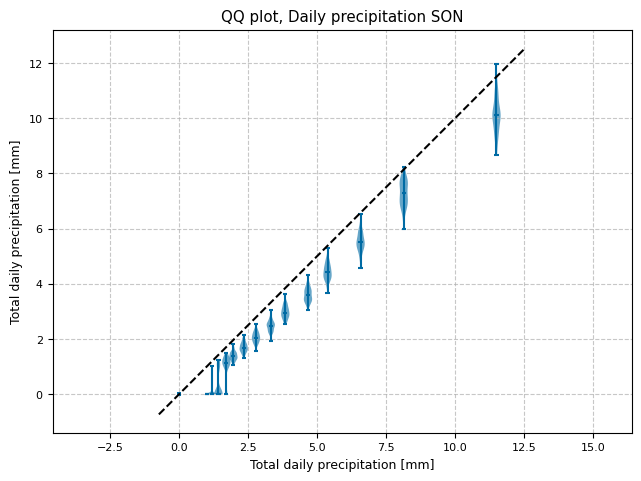

In [17]:
# qq plot for all days:

quantiles = np.linspace(0.025, 0.975, 39)

for i, (name_season, months) in enumerate(SEASONS.items()):
    fig, ax = plt.subplots()

    print("compute aggregates for ground truth")
    tp_gt = extract_datapoints_in_months(ground_truth, months=months).load()["tp"]
    tp = (
        ds_reforecasts_bias_corrected.sel(COORDS_LEIPZIG, method="nearest")
        .drop_vars("valid_time")
        .sel(trimmed_trajs.load())
        .rename({"out_time": "valid_time"})
    )["tp"]
    tp = extract_datapoints_in_months(tp, months=months).load()

    tp_quantiles = tp.quantile(quantiles, dim="valid_time").squeeze().transpose()
    tp_quantiles_gt = tp_gt.quantile(quantiles)

    ax.set_title("QQ plot, Daily precipitation " + name_season)

    positions = tp_quantiles_gt.values
    violin_data = tp_quantiles

    parts = plt.violinplot(
        violin_data, positions=positions, widths=0.3, showmedians=True
    )
    for pc in parts["bodies"]:
        # pc.set_facecolor('lightblue')
        pc.set_alpha(0.6)
        # pc.set_edgecolor('blue')
        # pc.set_linewidth(1)

    plt.axis("equal")
    plt.xlabel("Total daily precipitation [mm]")
    plt.ylabel("Total daily precipitation [mm]")
    xlim = plt.xlim()
    ylim = plt.ylim()
    vmin = min(xlim[0], ylim[0])
    vmax = max(xlim[1], ylim[1])
    plt.plot([vmin, vmax], [vmin, vmax], linestyle="dashed", color="k")

    plt.savefig(
        os.path.join(paths["dir_images"], f"qq_precip_{name_season}_all_days.png")
    )
    plt.show()